# FRAME-FM foundation model demo

This notebook is a small end-to-end example of using the FRAME-FM
workflow on local environmental data.

The workflow is:

1. use LCM percent-cover as the static spatial context;
2. use the available CHESS-Met variables as the dynamic meteorological context;
3. pretrain a compact multimodal autoencoder on random CHESS/LCM samples;
4. transfer the encoders to a COSMOS-UK soil-moisture regression task.

The notebook is deliberately kept smaller than the production framework. The point here is to show the data plumbing and the foundation-model pattern clearly: static branch + dynamic branch, self-supervised pretraining, then a supervised downstream task.

A couple of practical choices are worth noting. CHESS is not read one scalar at a time, because that is far too slow. For the current working period I cache the selected CHESS data in memory once, then train from that array. The project Zarr utilities are also wired in as an optional route for larger runs.


In [1]:

import json
import re
import sys
import warnings
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(7)
torch.manual_seed(7)

# Use the GPU for model training if PyTorch can see one. Raster/NetCDF reads still
# happen on CPU, so GPU utilisation will depend on how quickly batches are prepared.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Using torch device:", DEVICE)

PROJECT_ROOT = Path("[YOUR PROJECT ROOT]")  # set this to my local repo checkout
PROJECT_SRC = PROJECT_ROOT / "src"
if PROJECT_SRC.exists() and str(PROJECT_SRC) not in sys.path:
    sys.path.insert(0, str(PROJECT_SRC))

# Import the project data helpers when the local package is available. The notebook
# keeps plain xarray fallbacks so it can still run from a checkout.
try:
    from FRAME_FM.utils.data_utils import load_data_from_uri as frame_load_data_from_uri
    from FRAME_FM.utils.data_utils import write_zarr as frame_write_zarr

    HAVE_FRAME_FM_DATA_UTILS = True
except Exception as exc:
    frame_load_data_from_uri = None
    frame_write_zarr = None
    HAVE_FRAME_FM_DATA_UTILS = False
    FRAME_FM_IMPORT_ERROR = repr(exc)

DATA_REPO = PROJECT_ROOT / "[YOUR DATA ROOT]"
LAND_DIR = DATA_REPO / "LCM2015"
COSMOS_DIR = DATA_REPO / "cosmos"
SITE_META_CSV = DATA_REPO / "cosmos-uk_sitemetadata_2013-2024.csv"
CHESS_DIR = DATA_REPO / "chessmet_subset"

# A 7-day window keeps the dynamic input simple and lines up with the earlier demo.
WINDOW_DAYS = 7

# Optional sampled normalisation path. The memory-cache cell below computes exact
# stats for the selected working period; this is kept for larger experiments.
NORMALISATION_SAMPLE_POINTS = 8000
NORMALISATION_BATCH_SIZE = 1024
RUN_NORMALISATION_FIT = False
NORMALISATION_STATS_JSON = PROJECT_ROOT / "outputs" / "chess_met_normalisation_stats.json"

# Optional project-style Zarr cache. Building it is a preprocessing step, so it is not
# triggered automatically during the normal notebook run.
CHESS_ZARR_CACHE = PROJECT_ROOT / "outputs" / "chess_met_window_source.zarr"
USE_PROJECT_ZARR_CACHE_FOR_PLOTS = False

PLOT_SAMPLE_TIMES = 24
RUN_EXPENSIVE_PLOTS = False

# Draw a fixed number of random CHESS samples per epoch. This avoids materialising a
# huge grid-cell x date dataset just to shuffle it.
SAMPLES_PER_PRETRAIN_EPOCH = 1024
PRETRAIN_BATCH_SIZE = 256
PRETRAIN_EPOCHS = 50

# Leave this as None for the configured number of random samples per epoch. Set it to
# a small number for a smoke test.
PRETRAIN_MAX_BATCHES_PER_EPOCH = None

# Downstream training uses every COSMOS record in the CHESS overlap. This just avoids
# keeping sites with too little data to make a held-out-site split meaningful.
MIN_SITE_OBS = 20
DOWNSTREAM_CHESS_BATCH_SIZE = 2048

LAND_TIF_CANDIDATES = sorted(LAND_DIR.glob("*.tif"))
assert LAND_TIF_CANDIDATES, f"no land-cover tif found in {LAND_DIR}"
LAND_TIF = LAND_TIF_CANDIDATES[0]

assert DATA_REPO.exists(), f"repo folder not found: {DATA_REPO}"
assert COSMOS_DIR.exists(), f"COSMOS folder not found: {COSMOS_DIR}"
assert CHESS_DIR.exists(), f"CHESS folder not found: {CHESS_DIR}"
assert SITE_META_CSV.exists(), f"site metadata file not found: {SITE_META_CSV}"


def build_chess_index(chess_dir):
    """Read the NetCDF headers and record which variables/date ranges are available."""
    rows = []
    nc_files = sorted(chess_dir.rglob("*.nc"))
    assert nc_files, f"no CHESS NetCDF files found in {chess_dir}"

    for path in nc_files:
        try:
            with xr.open_dataset(path) as ds:
                time_start = pd.to_datetime(ds.time.values[0]).date() if "time" in ds.coords else pd.NaT
                time_end = pd.to_datetime(ds.time.values[-1]).date() if "time" in ds.coords else pd.NaT

                for variable in ds.data_vars:
                    da = ds[variable]
                    rows.append(
                        {
                            "path": path,
                            "file": path.name,
                            "variable": variable,
                            "dims": tuple(da.dims),
                            "time_start": time_start,
                            "time_end": time_end,
                            "shape": tuple(da.shape),
                        }
                    )
        except Exception as exc:
            rows.append(
                {
                    "path": path,
                    "file": path.name,
                    "variable": "__unreadable__",
                    "dims": (),
                    "time_start": pd.NaT,
                    "time_end": pd.NaT,
                    "shape": (),
                    "error": str(exc),
                }
            )
    return pd.DataFrame(rows)


def open_chess_variable(chess_index, variable):
    """Open all files for a single CHESS variable and merge them along time."""
    file_rows = chess_index.loc[chess_index["variable"] == variable].copy()
    assert not file_rows.empty, f"no CHESS files found for variable={variable!r} in {CHESS_DIR}"

    datasets = []
    for path in file_rows["path"].tolist():
        # No .load() here. This is only used for optional plotting/cache work.
        ds = xr.open_dataset(path)[[variable]]
        datasets.append(ds)

    if len(datasets) == 1:
        combined = datasets[0]
    else:
        combined = xr.concat(datasets, dim="time").sortby("time")
        _, keep_idx = np.unique(combined.time.values, return_index=True)
        combined = combined.isel(time=np.sort(keep_idx))

    return combined


def load_chess_stack(chess_index, variables=None):
    """Open the dynamic branch as variable x time x y x x without loading data.

    This is mainly for optional plots and Zarr caching. Training uses the point-window
    reader below, or the in-memory cache when the selected period is small enough.
    """
    candidate_rows = chess_index.loc[
        (chess_index["variable"] != "__unreadable__")
        & chess_index["dims"].apply(lambda d: {"time", "y", "x"}.issubset(set(d)))
        ].copy()

    available = sorted(candidate_rows["variable"].unique())
    selected = available if variables is None else [v for v in variables if v in available]
    assert selected, "no gridded CHESS variables with time/y/x dimensions were found"

    arrays = []
    kept = []
    for variable in selected:
        da = open_chess_variable(chess_index, variable)[variable].transpose("time", "y", "x")

        # CHESS precipitation is in kg m-2 s-1, so I convert it to mm/day for the raw
        # summaries. The model later sees a standardised version of every variable.
        if variable.lower() in {"precip", "precipitation"}:
            da = da * 86400.0
            da.attrs["units"] = "mm day-1"

        arrays.append(da.astype("float32"))
        kept.append(variable)

    aligned = xr.align(*arrays, join="inner")
    stack = xr.concat(aligned, dim=pd.Index(kept, name="variable")).sortby("time")
    return stack


chess_index = build_chess_index(CHESS_DIR)

print("Repo:", DATA_REPO)
print("Land cover:", LAND_TIF.name)
print("CHESS folder:", CHESS_DIR)
print("COSMOS folder:", COSMOS_DIR)
print("Site metadata:", SITE_META_CSV.name)
print("FRAME-FM data utils available:", HAVE_FRAME_FM_DATA_UTILS)
if not HAVE_FRAME_FM_DATA_UTILS:
    print("FRAME-FM data utils import skipped:", FRAME_FM_IMPORT_ERROR)


Using torch device: cuda
Repo: /home/niarn/PycharmProjects/FRAME-FM/data/data
Land cover: LCM2015_GB_1km_percent_cover_aggregate_class.tif
CHESS folder: /home/niarn/PycharmProjects/FRAME-FM/data/data/chessmet_subset
COSMOS folder: /home/niarn/PycharmProjects/FRAME-FM/data/data/cosmos
Site metadata: cosmos-uk_sitemetadata_2013-2024.csv
FRAME-FM data utils available: True


## Project setup


In [2]:

repo_bits = [
    "src/FRAME_FM/utils/data_utils.py",
    "src/FRAME_FM/dataloaders/combined_dataloader.py",
    "src/FRAME_FM/models/mmmae.py",
    "configs/data/demonstrator_datasets.yaml",
    "src/FRAME_FM/datasets/cosmosuk_dataset.py",
]

for rel in repo_bits:
    path = PROJECT_ROOT / rel
    print(f"{rel}: {'ok' if path.exists() else 'missing'}")

print("Using FRAME-FM data utilities in this notebook:", HAVE_FRAME_FM_DATA_UTILS)
print("Project pattern used here: batch/cache gridded reads instead of scanning raw NetCDF repeatedly.")


src/FRAME_FM/utils/data_utils.py: ok
src/FRAME_FM/dataloaders/combined_dataloader.py: ok
src/FRAME_FM/models/mmmae.py: ok
configs/data/demonstrator_datasets.yaml: ok
src/FRAME_FM/datasets/cosmosuk_dataset.py: ok
Using FRAME-FM data utilities in this notebook: True
Project pattern used here: batch/cache gridded reads instead of scanning raw NetCDF repeatedly.


The main project code already contains the pieces I would expect for a larger run: Zarr/data utilities, dataset wrappers, dataloaders and model components. This notebook stays self-contained, but reuses the project layout and keeps an optional hook into the project Zarr writer.


## Data loading and alignment

The first step is just bookkeeping: find the LCM raster, index the CHESS files from their headers, and work out the dates shared by the selected CHESS variables. I avoid loading any gridded CHESS arrays in this section unless they are needed for the later memory cache.


In [3]:

with rasterio.open(LAND_TIF) as src:
    # Metadata only here. The LCM values are sampled later at the points used by
    # pretraining/downstream batches.
    land_shape = (src.count, src.height, src.width)
    land_crs = src.crs
    land_bounds = src.bounds
    land_transform = src.transform

chess_index = chess_index.sort_values(["variable", "time_start", "file"]).reset_index(drop=True)

candidate_rows = chess_index.loc[
    (chess_index["variable"] != "__unreadable__")
    & chess_index["dims"].apply(lambda d: {"time", "y", "x"}.issubset(set(d)))
    ].copy()

chess_variables = sorted(candidate_rows["variable"].drop_duplicates().astype(str).tolist())
assert chess_variables, "no gridded CHESS variables with time/y/x dimensions were found"

chess_summary = candidate_rows.groupby("variable")[["time_start", "time_end"]].agg(["min", "max"])
display(chess_summary)


def _date_index_for_variable(file_rows):
    """Build a daily date index from CHESS file headers without opening arrays."""
    date_parts = []
    for _, file_row in file_rows.iterrows():
        start = pd.Timestamp(file_row["time_start"])
        end = pd.Timestamp(file_row["time_end"])
        if pd.isna(start) or pd.isna(end):
            continue
        date_parts.append(pd.date_range(start.normalize(), end.normalize(), freq="D"))

    if not date_parts:
        return pd.DatetimeIndex([])

    return pd.DatetimeIndex(sorted(set().union(*[set(d) for d in date_parts])))


# Work out the shared CHESS period from headers only. This is cheap and avoids
# constructing a variable x time x y x x array during setup.
shared_dates = None
for variable in chess_variables:
    variable_dates = _date_index_for_variable(candidate_rows.loc[candidate_rows["variable"] == variable])
    shared_dates = variable_dates if shared_dates is None else shared_dates.intersection(variable_dates)

chess_times = pd.to_datetime(shared_dates)
assert len(chess_times) >= WINDOW_DAYS, "not enough shared CHESS dates for the requested window"


def read_chess_coords_from_header(chess_index, variable):
    """Read the 1D CHESS coordinates from one NetCDF header."""
    path = chess_index.loc[chess_index["variable"] == variable, "path"].iloc[0]
    with xr.open_dataset(path) as ds:
        x = ds["x"].values.astype("float64")
        y = ds["y"].values.astype("float64")
    return x, y


xvals, yvals = read_chess_coords_from_header(candidate_rows, chess_variables[0])

# Initial values. These are replaced by cached stats, the optional sampled fit, or the
# exact stats from the memory-cache cell.
met_mean_values = np.zeros(len(chess_variables), dtype="float32")
met_std_values = np.ones(len(chess_variables), dtype="float32")

# Lookup table for date -> source file. This keeps the NetCDF reader explicit and
# avoids building a large multi-file xarray object for normal batches.
chess_file_table = candidate_rows.copy()
chess_file_table["time_start"] = pd.to_datetime(chess_file_table["time_start"]).dt.normalize()
chess_file_table["time_end"] = pd.to_datetime(chess_file_table["time_end"]).dt.normalize()


@lru_cache(maxsize=256)
def open_chess_file(path):
    """Open one CHESS NetCDF file and keep the handle for repeated batch reads."""
    # For point batches, plain xarray is usually quicker than adding Dask overhead.
    # The project Zarr route is kept separate for larger preprocessing jobs.
    return xr.open_dataset(Path(path))


@lru_cache(maxsize=1)
def get_chess_stack():
    """Open the CHESS stack lazily, mainly for optional plotting/cache work."""
    return load_chess_stack(chess_index, variables=chess_variables)


def build_project_style_chess_zarr(cache_path=CHESS_ZARR_CACHE, overwrite=False):
    """Optional one-off cache using the FRAME-FM Zarr pattern.

    This is not run automatically. For a larger run, this creates a lazy xarray stack,
    chunks it, and writes it as Zarr using the project helper when available.
    """
    cache_path = Path(cache_path)
    if cache_path.exists() and not overwrite:
        return xr.open_zarr(cache_path, chunks={"time": 64})

    stack = get_chess_stack().chunk({"time": 64, "y": 256, "x": 256, "variable": 1})
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if HAVE_FRAME_FM_DATA_UTILS and frame_write_zarr is not None:
        frame_write_zarr(stack.to_dataset(name="chess_met"), cache_path, chunks={"time": 64, "y": 256, "x": 256})
    else:
        stack.to_dataset(name="chess_met").to_zarr(cache_path, mode="w")

    return xr.open_zarr(cache_path, chunks={"time": 64})


def _rows_for_variable(variable):
    """Return the file rows for one variable, sorted in time order."""
    rows = chess_file_table.loc[chess_file_table["variable"] == variable].copy()
    return rows.sort_values(["time_start", "time_end", "file"]).reset_index(drop=True)


def _convert_units_if_needed(variable, values):
    """Keep precipitation on the same mm/day scale as the earlier notebook."""
    if variable.lower() in {"precip", "precipitation"}:
        return values * 86400.0
    return values


def read_chess_windows_batched(time_idx, y_idx, x_idx, window_days=WINDOW_DAYS):
    """Read CHESS windows for many point samples at once.

    This avoids the slow pattern of requesting one NetCDF scalar per sample. Requests
    are grouped by variable, window offset and source file, then read with vectorised
    xarray indexing.
    """
    time_idx = np.asarray(time_idx, dtype="int64").reshape(-1)
    y_idx = np.asarray(y_idx, dtype="int64").reshape(-1)
    x_idx = np.asarray(x_idx, dtype="int64").reshape(-1)

    assert len(time_idx) == len(y_idx) == len(x_idx), "time/y/x index arrays must match"
    assert np.all(time_idx >= window_days - 1), "each sample needs a complete history window"
    assert np.all(time_idx < len(chess_times)), "time index out of range"

    n = len(time_idx)
    raw = np.full((n, window_days, len(chess_variables)), np.nan, dtype="float32")

    for v, variable in enumerate(chess_variables):
        variable_rows = _rows_for_variable(variable)

        for w in range(window_days):
            dates = pd.DatetimeIndex(chess_times[time_idx - window_days + 1 + w]).normalize()

            for _, file_row in variable_rows.iterrows():
                in_file = (dates >= file_row["time_start"]) & (dates <= file_row["time_end"])
                if not np.any(in_file):
                    continue

                sample_pos = np.flatnonzero(in_file)
                local_t = np.asarray((dates[in_file] - file_row["time_start"]).days, dtype="int64")
                yy = y_idx[in_file].astype("int64")
                xx = x_idx[in_file].astype("int64")

                ds = open_chess_file(str(file_row["path"]))

                values = (
                    ds[variable]
                    .isel(
                        time=xr.DataArray(local_t, dims="sample"),
                        y=xr.DataArray(yy, dims="sample"),
                        x=xr.DataArray(xx, dims="sample"),
                    )
                    .values
                    .astype("float32")
                    .reshape(-1)
                )

                raw[sample_pos, w, v] = _convert_units_if_needed(variable, values)

    norm = standardise_chess(raw)
    return raw, norm


def standardise_chess(raw_values):
    """Apply the current CHESS normalisation to a raw window or block."""
    return ((raw_values - met_mean_values) / met_std_values).astype("float32")


@lru_cache(maxsize=200000)
def get_chess_point_window(time_idx, y_idx, x_idx):
    """Read one CHESS window for debug/plotting calls.

    The main pretraining and COSMOS table code uses read_chess_windows_batched.
    """
    raw, norm = read_chess_windows_batched([int(time_idx)], [int(y_idx)], [int(x_idx)])
    return raw[0], norm[0]


def fit_chess_normalisation_batched(n_samples=NORMALISATION_SAMPLE_POINTS, batch_size=NORMALISATION_BATCH_SIZE,
                                    random_state=7):
    """Estimate per-variable CHESS mean/std from random training-style windows.

    This uses the same batched reader as training, so it avoids the slow scalar-read
    pattern while still giving sensible per-variable scaling.
    """
    global met_mean_values, met_std_values

    rng = np.random.default_rng(random_state)
    n_samples = int(min(n_samples, (len(chess_times) - WINDOW_DAYS + 1) * len(yvals) * len(xvals)))

    sums = np.zeros(len(chess_variables), dtype="float64")
    sums_sq = np.zeros(len(chess_variables), dtype="float64")
    counts = np.zeros(len(chess_variables), dtype="int64")

    for start in range(0, n_samples, batch_size):
        n_batch = min(batch_size, n_samples - start)
        t = rng.integers(WINDOW_DAYS - 1, len(chess_times), size=n_batch)
        y = rng.integers(0, len(yvals), size=n_batch)
        x = rng.integers(0, len(xvals), size=n_batch)

        raw, _ = read_chess_windows_batched(t, y, x)
        flat = raw.reshape(-1, len(chess_variables))

        finite = np.isfinite(flat)
        safe = np.where(finite, flat, 0.0).astype("float64")

        sums += safe.sum(axis=0)
        sums_sq += (safe * safe).sum(axis=0)
        counts += finite.sum(axis=0)

    mean = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
    var = np.divide(sums_sq, counts, out=np.ones_like(sums_sq), where=counts > 0) - mean ** 2
    std = np.sqrt(np.maximum(var, 1e-12))

    met_mean_values = mean.astype("float32")
    met_std_values = np.where(np.isfinite(std) & (std > 1e-6), std, 1.0).astype("float32")

    get_chess_point_window.cache_clear()

    norm_table = pd.DataFrame(
        {
            "variable": chess_variables,
            "mean": met_mean_values,
            "std": met_std_values,
            "finite_values": counts,
        }
    )
    display(norm_table)
    return met_mean_values, met_std_values


def load_chess_normalisation_stats(path=NORMALISATION_STATS_JSON):
    """Load cached CHESS normalisation stats from JSON."""
    global met_mean_values, met_std_values

    with open(path, "r") as f:
        stats = json.load(f)

    missing = [v for v in chess_variables if v not in stats]
    if missing:
        raise KeyError(f"normalisation cache is missing variables: {missing}")

    met_mean_values = np.asarray([stats[v]["mean"] for v in chess_variables], dtype="float32")
    met_std_values = np.asarray([stats[v]["std"] for v in chess_variables], dtype="float32")
    met_std_values = np.where(
        np.isfinite(met_std_values) & (met_std_values > 1e-6),
        met_std_values,
        1.0,
    ).astype("float32")

    get_chess_point_window.cache_clear()
    return pd.DataFrame(
        {
            "variable": chess_variables,
            "mean": met_mean_values,
            "std": met_std_values,
            "source": str(path),
        }
    )


def save_chess_normalisation_stats(path=NORMALISATION_STATS_JSON):
    """Save the current CHESS normalisation stats so later runs start instantly."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    stats = {
        variable: {"mean": float(mean), "std": float(std)}
        for variable, mean, std in zip(chess_variables, met_mean_values, met_std_values)
    }

    with open(path, "w") as f:
        json.dump(stats, f, indent=2)

    return path


if NORMALISATION_STATS_JSON.exists():
    normalisation_table = load_chess_normalisation_stats(NORMALISATION_STATS_JSON)
    print(f"Loaded cached CHESS normalisation stats from {NORMALISATION_STATS_JSON}")
    display(normalisation_table)
elif RUN_NORMALISATION_FIT:
    fit_chess_normalisation_batched(n_samples=NORMALISATION_SAMPLE_POINTS)
    saved_to = save_chess_normalisation_stats(NORMALISATION_STATS_JSON)
    print(f"Saved CHESS normalisation stats to {saved_to}")
else:
    print(
        "No cached CHESS normalisation stats found. "
        "Leaving met_mean_values=0 and met_std_values=1 for now. "
        "Run the memory-cache cell or optional stats cell before serious training."
    )

summary = pd.DataFrame(
    [
        {
            "source": "Static LCM tif",
            "shape": str(land_shape),
            "crs": str(land_crs),
            "time_start": "",
            "time_end": "",
            "variables": land_shape[0],
        },
        {
            "source": "CHESS-Met index",
            "shape": str((len(chess_variables), len(chess_times), len(yvals), len(xvals))),
            "crs": "OSGB / EPSG:27700 via coords",
            "time_start": str(chess_times.min().date()),
            "time_end": str(chess_times.max().date()),
            "variables": ", ".join(chess_variables),
        },
    ]
)

summary


time_start                time_end            
                 min         max         min         max
variable                                                
huss      2015-05-01  2015-12-01  2015-05-31  2015-12-31
precip    2015-05-01  2015-12-01  2015-05-31  2015-12-31

No cached CHESS normalisation stats found. Leaving met_mean_values=0 and met_std_values=1 for now. Run the memory-cache cell or optional stats cell before serious training.


,source,shape,crs,time_start,time_end,variables
0,Static LCM tif,"(10, 1300, 700)",EPSG:27700,,,10
1,CHESS-Met index,"(2, 245, 1057, 656)",OSGB / EPSG:27700 via coords,2015-05-01,2015-12-31,"huss, precip"


In [4]:
# Fast CHESS cache for the current working period
#
# The batched NetCDF reader above is useful as a fallback, but repeated random reads
# from monthly files are still slow. For this demo-sized CHESS window I load the
# selected period once into a compact time x y x x x variable array and then train
# from ordinary NumPy indexing.

import time

CHESS_IN_MEMORY_CACHE = None
CHESS_IN_MEMORY_CACHE_META = None


def load_chess_period_to_memory(force=False):
    """Load the selected CHESS variables/dates once so batches are cheap.

    This is only for the already-filtered period in `chess_times` and the selected
    variables in `chess_variables`. With a short working period this is much smaller
    than the full CHESS archive and avoids repeated random NetCDF reads.
    """
    global CHESS_IN_MEMORY_CACHE, CHESS_IN_MEMORY_CACHE_META
    global met_mean_values, met_std_values

    if CHESS_IN_MEMORY_CACHE is not None and not force:
        return CHESS_IN_MEMORY_CACHE

    t0 = time.perf_counter()
    n_time = len(chess_times)
    n_y = len(yvals)
    n_x = len(xvals)
    n_var = len(chess_variables)

    est_gb = n_time * n_y * n_x * n_var * np.dtype("float32").itemsize / 1024 ** 3
    print(f"Building CHESS memory cache: {n_time} days x {n_y} rows x {n_x} cols x {n_var} vars")
    print(f"Estimated cache size: {est_gb:.2f} GB")

    cache = np.full((n_time, n_y, n_x, n_var), np.nan, dtype="float32")
    time_lookup_local = {pd.Timestamp(t).normalize(): i for i, t in enumerate(chess_times)}

    for v, variable in enumerate(chess_variables):
        rows = _rows_for_variable(variable)

        for _, file_row in rows.iterrows():
            file_start = pd.Timestamp(file_row["time_start"]).normalize()
            file_end = pd.Timestamp(file_row["time_end"]).normalize()

            overlap = pd.DatetimeIndex(chess_times).intersection(
                pd.date_range(file_start, file_end, freq="D")
            )
            if len(overlap) == 0:
                continue

            global_t = np.asarray([time_lookup_local[pd.Timestamp(d).normalize()] for d in overlap], dtype="int64")
            local_t = np.asarray((overlap - file_start).days, dtype="int64")

            with xr.open_dataset(file_row["path"]) as ds:
                arr = (
                    ds[variable]
                    .transpose("time", "y", "x")
                    .isel(time=xr.DataArray(local_t, dims="time"))
                    .values
                    .astype("float32")
                )

            cache[global_t, :, :, v] = _convert_units_if_needed(variable, arr)
            print(f"  loaded {variable:>10s} | {file_row['file']} | {len(overlap)} days")

    # Exact per-variable stats for the loaded working period. This is cheap once the
    # data are contiguous in memory.
    flat = cache.reshape(-1, n_var)
    met_mean_values = np.nanmean(flat, axis=0).astype("float32")
    met_std_values = np.nanstd(flat, axis=0).astype("float32")
    met_std_values = np.where(
        np.isfinite(met_std_values) & (met_std_values > 1e-6),
        met_std_values,
        1.0,
    ).astype("float32")

    CHESS_IN_MEMORY_CACHE = cache
    CHESS_IN_MEMORY_CACHE_META = {
        "shape": cache.shape,
        "variables": list(chess_variables),
        "time_start": str(pd.Timestamp(chess_times.min()).date()),
        "time_end": str(pd.Timestamp(chess_times.max()).date()),
        "estimated_gb": est_gb,
        "built_seconds": time.perf_counter() - t0,
    }

    get_chess_point_window.cache_clear()

    print(f"CHESS memory cache ready in {CHESS_IN_MEMORY_CACHE_META['built_seconds']:.1f}s")

    display(
        pd.DataFrame(
            {
                "variable": chess_variables,
                "mean": met_mean_values,
                "std": met_std_values,
            }
        )
    )

    return CHESS_IN_MEMORY_CACHE


def read_chess_windows_batched(time_idx, y_idx, x_idx, window_days=WINDOW_DAYS):
    """Read CHESS windows from the memory cache.

    This overrides the NetCDF-based function above but keeps the same interface, so the
    rest of the notebook can stay unchanged.
    """
    cache = load_chess_period_to_memory()

    time_idx = np.asarray(time_idx, dtype="int64").reshape(-1)
    y_idx = np.asarray(y_idx, dtype="int64").reshape(-1)
    x_idx = np.asarray(x_idx, dtype="int64").reshape(-1)

    assert len(time_idx) == len(y_idx) == len(x_idx), "time/y/x index arrays must match"
    assert np.all(time_idx >= window_days - 1), "each sample needs a complete history window"
    assert np.all(time_idx < cache.shape[0]), "time index out of range"

    # Broadcasted NumPy indexing gives shape: sample x window x variable.
    t_window = time_idx[:, None] - window_days + 1 + np.arange(window_days, dtype="int64")[None, :]
    raw = cache[t_window, y_idx[:, None], x_idx[:, None], :].astype("float32", copy=False)
    norm = standardise_chess(raw)
    return raw, norm


# Build the cache before training. This is the one-off cost; the pretraining cell then
# spends its time on model updates rather than random NetCDF I/O.
_ = load_chess_period_to_memory()


Building CHESS memory cache: 245 days x 1057 rows x 656 cols x 2 vars
Estimated cache size: 1.27 GB
  loaded       huss | chess-met_huss_gb_1km_daily_20150501-20150531.nc | 31 days
  loaded       huss | chess-met_huss_gb_1km_daily_20150601-20150630.nc | 30 days
  loaded       huss | chess-met_huss_gb_1km_daily_20150701-20150731.nc | 31 days
  loaded       huss | chess-met_huss_gb_1km_daily_20150801-20150831.nc | 31 days
  loaded       huss | chess-met_huss_gb_1km_daily_20150901-20150930.nc | 30 days
  loaded       huss | chess-met_huss_gb_1km_daily_20151001-20151031.nc | 31 days
  loaded       huss | chess-met_huss_gb_1km_daily_20151101-20151130.nc | 30 days
  loaded       huss | chess-met_huss_gb_1km_daily_20151201-20151231.nc | 31 days
  loaded     precip | chess-met_precip_gb_1km_daily_20150501-20150531.nc | 31 days
  loaded     precip | chess-met_precip_gb_1km_daily_20150601-20150630.nc | 30 days
  loaded     precip | chess-met_precip_gb_1km_daily_20150701-20150731.nc | 31 days
  l

,variable,mean,std
0,huss,0.004640,0.002353
1,precip,3.232478,6.343505


## Optional CHESS normalisation cache

The memory-cache path below computes exact mean/std values for the loaded working period, so I do not normally need this cell.

I have kept the sampled normalisation helper because it is useful when experimenting with a larger CHESS archive where loading the whole selected period into memory is not sensible. In that case the stats can be fitted once, saved to JSON, and reused on later runs.


In [5]:

# Optional one-off step for larger runs where the memory cache is not used.
# For the current memory-cache path, stats are calculated exactly in the cache cell.

if RUN_NORMALISATION_FIT:
    fit_chess_normalisation_batched(
        n_samples=NORMALISATION_SAMPLE_POINTS,
        batch_size=NORMALISATION_BATCH_SIZE,
    )
    saved_to = save_chess_normalisation_stats(NORMALISATION_STATS_JSON)
    print(f"Saved CHESS normalisation stats to {saved_to}")
else:
    print("RUN_NORMALISATION_FIT is False; skipping the sampled normalisation fit.")
    print("To fit once: set RUN_NORMALISATION_FIT=True in the config cell, then run this cell.")


RUN_NORMALISATION_FIT is False; skipping the sampled normalisation fit.
To fit once: set RUN_NORMALISATION_FIT=True in the config cell, then run this cell.


In [6]:

print("CHESS variables:", chess_variables)
print("Shared CHESS dates:", chess_times.min().date(), "to", chess_times.max().date())
print("CHESS grid:", len(yvals), "rows x", len(xvals), "cols")
print("CHESS x starts at", float(xvals[0]), "and ends at", float(xvals[-1]))
print("CHESS y starts at", float(yvals[0]), "and ends at", float(yvals[-1]))

if RUN_EXPENSIVE_PLOTS:
    # This preview reads one CHESS day from disk, so I keep it behind a switch. It is
    # useful for visual checking, but I do not want it slowing down a normal run.
    stack = get_chess_stack()
    first_day = stack.isel(time=0).transpose("y", "x", "variable").values.astype("float32")
    valid_mask = np.isfinite(first_day).all(axis=-1)

    plot_vars = chess_variables[: min(2, len(chess_variables))]
    fig, axes = plt.subplots(1, len(plot_vars) + 1, figsize=(5 * (len(plot_vars) + 1), 4.5))
    if len(plot_vars) + 1 == 1:
        axes = [axes]

    axes[0].imshow(valid_mask[::4, ::4], origin="lower")
    axes[0].set_title("Valid CHESS cells on first shared day")
    axes[0].set_xlabel("x index")
    axes[0].set_ylabel("y index")

    for ax, variable in zip(axes[1:], plot_vars):
        v_idx = chess_variables.index(variable)
        im = ax.imshow(first_day[:, :, v_idx], origin="lower")
        ax.set_title(f"CHESS {variable} on first shared day")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()
else:
    print("Skipping CHESS preview map. Set RUN_EXPENSIVE_PLOTS = True if I want to draw it.")


CHESS variables: ['huss', 'precip']
Shared CHESS dates: 2015-05-01 to 2015-12-31
CHESS grid: 1057 rows x 656 cols
CHESS x starts at 500.0 and ends at 655500.0
CHESS y starts at 500.0 and ends at 1056500.0
Skipping CHESS preview map. Set RUN_EXPENSIVE_PLOTS = True if I want to draw it.


The LCM raster is larger than the CHESS domain, which is fine. CHESS is the reference grid for the dynamic inputs, and LCM is sampled at the same grid cells or COSMOS site locations.


## Static land-cover branch

The static input is the LCM percent-cover vector. For this demonstration I use it directly rather than building a more complicated spatial encoder. It gives the model a basic description of the surface type at each sampled location.


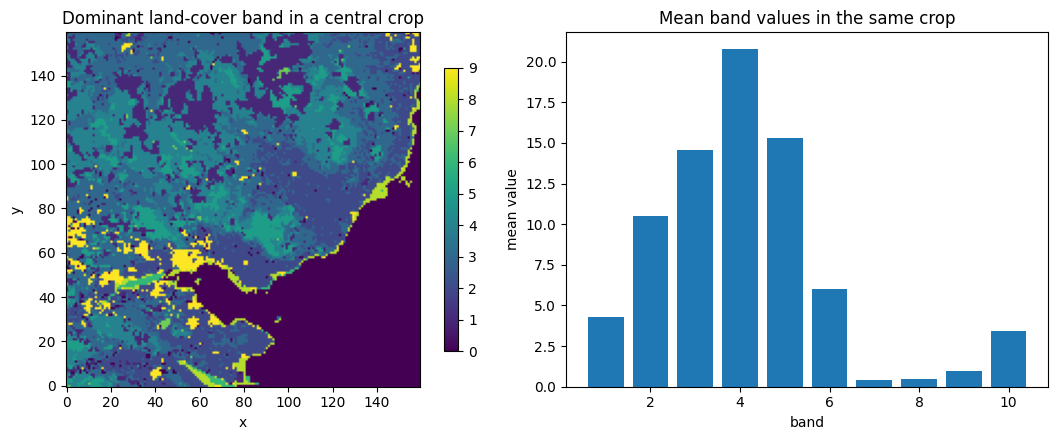

In [7]:

with rasterio.open(LAND_TIF) as src:
    # sample a central crop just to get a feel for the raster
    center_row = src.height // 2
    center_col = src.width // 2
    crop = src.read(
        window=((center_row - 80, center_row + 80), (center_col - 80, center_col + 80))
    ).astype("float32")

top_band = np.argmax(crop, axis=0)
band_means = crop.reshape(crop.shape[0], -1).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im = axes[0].imshow(top_band, origin="lower")
axes[0].set_title("Dominant land-cover band in a central crop")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im, ax=axes[0], shrink=0.8)

axes[1].bar(np.arange(1, len(band_means) + 1), band_means)
axes[1].set_title("Mean band values in the same crop")
axes[1].set_xlabel("band")
axes[1].set_ylabel("mean value")

plt.tight_layout()
plt.show()

## CHESS-Met dynamic branch

The dynamic branch is a short CHESS-Met history ending on the target day. Precipitation is converted to mm/day for summaries. The model input is the standardised window for each selected variable.


In [8]:

if RUN_EXPENSIVE_PLOTS:
    plot_vars = chess_variables[: min(2, len(chess_variables))]
    fig, axes = plt.subplots(1, len(plot_vars), figsize=(5.5 * len(plot_vars), 4.5))
    if len(plot_vars) == 1:
        axes = [axes]

    # This reads a small time sample from CHESS. It is only for visual checking; the
    # training datasets still use the full time range.
    stack = get_chess_stack()
    plot_time_idx = np.unique(
        np.linspace(0, len(chess_times) - 1, min(PLOT_SAMPLE_TIMES, len(chess_times))).astype(int)
    )

    for ax, variable in zip(axes, plot_vars):
        mean_map = (
            stack
            .sel(variable=variable)
            .isel(time=plot_time_idx)
            .mean("time", skipna=True)
            .values
        )
        im = ax.imshow(mean_map, origin="lower")
        ax.set_title(f"Sample mean {variable} over loaded period")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()
else:
    print("Skipping sampled CHESS mean maps. Set RUN_EXPENSIVE_PLOTS = True to run this check.")


Skipping sampled CHESS mean maps. Set RUN_EXPENSIVE_PLOTS = True to run this check.


## Foundation-model pretraining

The pretraining task is intentionally simple: reconstruct the static LCM vector and the CHESS-Met window from a fused latent representation. This is not meant to be the final architecture; it is a minimal demonstration of the FRAME-FM idea.

The important implementation detail is the sampling strategy. I do not enumerate every `(time, y, x)` combination or shuffle a huge map-style dataset. Each epoch draws a fixed number of random CHESS grid cells and dates from the available period.


In [9]:

def read_landcover_batch(x, y):
    """Sample static LCM vectors for a batch of OSGB coordinates."""
    x = np.asarray(x, dtype="float64").reshape(-1)
    y = np.asarray(y, dtype="float64").reshape(-1)

    with rasterio.open(LAND_TIF) as src:
        values = np.asarray(list(src.sample(zip(x, y))), dtype="float32") / 100.0

    # Treat each vector as fractions. This also makes the input robust to small
    # encoding differences in the raster.
    totals = values.sum(axis=1, keepdims=True)
    values = np.divide(values, totals, out=np.zeros_like(values), where=totals > 0)
    return values.astype("float32")


@lru_cache(maxsize=500000)
def read_landcover_vector(x, y):
    """Single-point wrapper used by a few plotting/debug cells."""
    return read_landcover_batch([float(x)], [float(y)])[0]


def make_random_pretrain_batch(batch_size, rng):
    """Draw one random CHESS/LCM batch from the available grid and time range.

    Sampling directly is simpler than building the full len(y) x len(x) x len(time)
    Cartesian product and then shuffling it.
    """
    batch_size = int(batch_size)

    time_idx = rng.integers(WINDOW_DAYS - 1, len(chess_times), size=batch_size)
    row_idx = rng.integers(0, len(yvals), size=batch_size)
    col_idx = rng.integers(0, len(xvals), size=batch_size)

    land_np = read_landcover_batch(xvals[col_idx], yvals[row_idx])
    _, met_np = read_chess_windows_batched(time_idx, row_idx, col_idx)

    met_np = np.nan_to_num(met_np, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
    return (
        torch.from_numpy(land_np),
        torch.from_numpy(met_np.reshape(batch_size, -1)),
    )


met_feature_dim = WINDOW_DAYS * len(chess_variables)
land_feature_dim = land_shape[0]

pretrain_batches_per_epoch = int(np.ceil(SAMPLES_PER_PRETRAIN_EPOCH / PRETRAIN_BATCH_SIZE))
if PRETRAIN_MAX_BATCHES_PER_EPOCH is not None:
    pretrain_batches_per_epoch = min(pretrain_batches_per_epoch, int(PRETRAIN_MAX_BATCHES_PER_EPOCH))

print("pretraining random samples per epoch:", SAMPLES_PER_PRETRAIN_EPOCH)
print("pretraining batches per epoch:", pretrain_batches_per_epoch)
print("land feature dim:", land_feature_dim)
print("met feature dim:", met_feature_dim)


pretraining random samples per epoch: 1024
pretraining batches per epoch: 4
land feature dim: 10
met feature dim: 14


In [10]:

class SpaceEncoder(nn.Module):
    """Small encoder for the static LCM vector."""

    def __init__(self, in_dim, d=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, d),
        )

    def forward(self, x):
        return self.net(x)


class MetEncoder(nn.Module):
    """Small encoder for the flattened CHESS-Met window."""

    def __init__(self, in_dim, d=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, d),
        )

    def forward(self, x):
        return self.net(x)


class TinyMultimodalAE(nn.Module):
    """Minimal two-branch autoencoder used for the FRAME-FM demonstration."""

    def __init__(self, land_dim, met_dim, d=16):
        super().__init__()
        self.space = SpaceEncoder(land_dim, d)
        self.met = MetEncoder(met_dim, d)
        self.fuse = nn.Sequential(
            nn.Linear(2 * d, 32),
            nn.ReLU(),
            nn.Linear(32, d),
        )
        self.land_decoder = nn.Sequential(
            nn.Linear(d, 32),
            nn.ReLU(),
            nn.Linear(32, land_dim),
            nn.Sigmoid(),
        )
        self.met_decoder = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, met_dim),
        )

    def forward(self, land, met):
        z_land = self.space(land)
        z_met = self.met(met)
        z = self.fuse(torch.cat([z_land, z_met], dim=1))
        return self.land_decoder(z), self.met_decoder(z), z


pretrain_model = TinyMultimodalAE(land_dim=land_feature_dim, met_dim=met_feature_dim, d=16).to(DEVICE)
opt = torch.optim.Adam(pretrain_model.parameters(), lr=1e-3)

history = []
for epoch in range(PRETRAIN_EPOCHS):
    epoch_t0 = time.perf_counter()
    read_seconds = 0.0
    train_seconds = 0.0
    batch_losses = []
    rng = np.random.default_rng(10_000 + epoch)

    for batch_idx in range(pretrain_batches_per_epoch):
        this_batch_size = min(
            PRETRAIN_BATCH_SIZE,
            SAMPLES_PER_PRETRAIN_EPOCH - batch_idx * PRETRAIN_BATCH_SIZE,
        )
        if this_batch_size <= 0:
            break

        batch_t0 = time.perf_counter()
        land_batch, met_batch = make_random_pretrain_batch(this_batch_size, rng)
        read_seconds += time.perf_counter() - batch_t0

        train_t0 = time.perf_counter()
        land_batch = land_batch.to(DEVICE, non_blocking=True)
        met_batch = met_batch.to(DEVICE, non_blocking=True)

        land_hat, met_hat, _ = pretrain_model(land_batch, met_batch)
        loss = F.mse_loss(land_hat, land_batch) + F.mse_loss(met_hat, met_batch)

        opt.zero_grad()
        loss.backward()
        opt.step()
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        train_seconds += time.perf_counter() - train_t0

        batch_losses.append(loss.item())

    history.append(float(np.mean(batch_losses)))
    epoch_seconds = time.perf_counter() - epoch_t0
    print(
        f"epoch {epoch + 1:02d} | loss {history[-1]:.4f} | batches {len(batch_losses)} | "
        f"read {read_seconds:.1f}s | train {train_seconds:.1f}s | total {epoch_seconds:.1f}s"
    )

history[:5], history[-3:]


epoch 01 | loss 0.6841 | batches 4 | read 0.1s | train 0.3s | total 0.4s
epoch 02 | loss 0.6454 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 03 | loss 0.6883 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 04 | loss 0.6702 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 05 | loss 0.5618 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 06 | loss 0.5921 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 07 | loss 0.4924 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 08 | loss 0.4503 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 09 | loss 0.5468 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 10 | loss 0.3975 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 11 | loss 0.4836 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 12 | loss 0.3669 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 13 | loss 0.3236 | batches 4 | read 0.1s | train 0.0s | total 0.1s
epoch 14 | loss 0.2797 | batches 4 | read 0.1s | tr

([0.6841292232275009,
  0.6453817486763,
  0.6882543116807938,
  0.6702155321836472,
  0.5618009865283966],
 [0.11024226807057858, 0.13586222380399704, 0.13015935756266117])

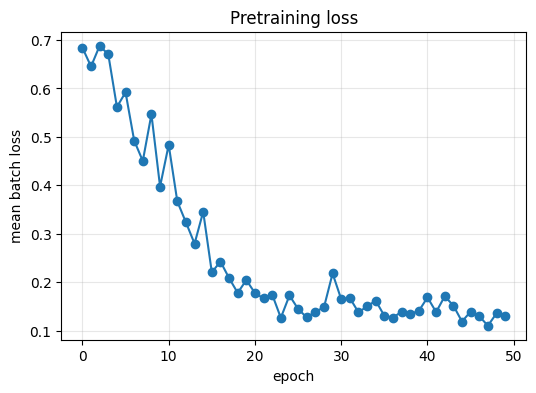

In [12]:

plt.figure(figsize=(6, 4))
plt.plot(history, marker="o")
plt.title("Pretraining loss")
plt.xlabel("epoch")
plt.ylabel("mean batch loss")
plt.grid(True, alpha=0.3)
plt.show()

The pretraining loss is only a sanity check. I am mainly checking that the two branches learn a stable shared representation that can be reused for the supervised COSMOS task.


## COSMOS daily targets

COSMOS provides the downstream target. I join the daily site records to the CHESS grid using the site coordinates and keep records that have:

- a valid `COSMOS_VWC` target;
- matched site metadata;
- coordinates inside the CHESS grid;
- dates inside the shared CHESS-Met period.


In [13]:
# COSMOS daily files are one CSV per site. Flag files are separate, so skip them here.
daily_files = sorted(
    [
        p for p in COSMOS_DIR.glob("*hydrosoil_daily_*.csv")
        if "flags" not in p.name.lower()
    ]
)


def load_daily_site_csv(path):
    df = pd.read_csv(path).replace(-9999, np.nan)
    df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])
    site_id = re.search(r"cosmos-uk_(.*?)_hydrosoil_daily", path.name).group(1).upper()
    df["SITE_ID"] = site_id
    return df


site_meta = pd.read_csv(SITE_META_CSV)
keep_meta = [
    "SITE_ID",
    "SITE_NAME",
    "EASTING",
    "NORTHING",
    "LATITUDE",
    "LONGITUDE",
    "SOIL_TYPE",
    "LAND_COVER",
    "START_DATE",
    "END_DATE",
]

site_rows = []
site_frames = []

for path in daily_files:
    df = load_daily_site_csv(path)
    df = df.merge(site_meta[keep_meta], on="SITE_ID", how="left")
    site_frames.append(df)
    site_rows.append(
        {
            "site_id": df["SITE_ID"].iloc[0],
            "start": df["DATE_TIME"].min().date(),
            "end": df["DATE_TIME"].max().date(),
            "rows": len(df),
            "valid_cosmos_vwc": int(df["COSMOS_VWC"].notna().sum()),
            "has_metadata": bool(df["EASTING"].notna().any()),
        }
    )

site_summary = pd.DataFrame(site_rows).sort_values("site_id").reset_index(drop=True)
all_daily = pd.concat(site_frames, ignore_index=True)

print("Daily COSMOS files:", len(daily_files))
print("Sites in metadata table:", site_meta["SITE_ID"].nunique())
print("Files with matched metadata:", int(site_summary["has_metadata"].sum()))
site_summary.head(10)

Daily COSMOS files: 51
Sites in metadata table: 51
Files with matched metadata: 51


,site_id,start,end,rows,valid_cosmos_vwc,has_metadata
0,ALIC1,2015-03-06,2024-12-31,3589,3473,True
1,BALRD,2014-05-15,2024-12-31,3884,3833,True
2,BICKL,2015-01-28,2024-12-31,3626,3574,True
3,BUNNY,2015-01-27,2024-12-31,3627,3599,True
4,CARDT,2015-06-24,2024-12-31,3479,3452,True
5,CGARW,2016-06-29,2024-12-31,3108,2935,True
6,CHIMN,2013-10-02,2024-12-31,4109,4044,True
7,CHOBH,2015-02-24,2024-12-31,3599,3598,True
8,COCHN,2017-08-23,2024-12-31,2688,1178,True
9,COCLP,2014-11-21,2024-12-31,3694,3451,True


In [14]:

cosmos_daily = all_daily.dropna(subset=["COSMOS_VWC", "EASTING", "NORTHING"]).copy()

x_min, x_max = sorted((float(np.nanmin(xvals)), float(np.nanmax(xvals))))
y_min, y_max = sorted((float(np.nanmin(yvals)), float(np.nanmax(yvals))))

cosmos_daily["inside_chess"] = (
        cosmos_daily["EASTING"].between(x_min, x_max)
        & cosmos_daily["NORTHING"].between(y_min, y_max)
)
cosmos_daily["in_chess_time"] = cosmos_daily["DATE_TIME"].isin(chess_times)

# Downstream pool: all COSMOS observations that can be paired with the loaded CHESS
# time range/grid and the static LCM raster.
cosmos_overlap = cosmos_daily.loc[
    cosmos_daily["inside_chess"] & cosmos_daily["in_chess_time"]
    ].reset_index(drop=True)

cosmos_counts = (
    cosmos_overlap.groupby("SITE_ID")
    .agg(
        n_obs=("COSMOS_VWC", "size"),
        first_day=("DATE_TIME", "min"),
        last_day=("DATE_TIME", "max"),
        inside_chess=("inside_chess", "max"),
    )
    .reset_index()
    .sort_values(["n_obs", "SITE_ID"], ascending=[False, True])
    .reset_index(drop=True)
)

print("COSMOS records after target/coordinate filtering:", len(cosmos_daily))
print("COSMOS records in CHESS space-time overlap:", len(cosmos_overlap))
cosmos_counts


COSMOS records after target/coordinate filtering: 161319
COSMOS records in CHESS space-time overlap: 7015


,SITE_ID,n_obs,first_day,last_day,inside_chess
0,ALIC1,245,2015-05-01,2015-12-31,True
1,BALRD,245,2015-05-01,2015-12-31,True
2,BICKL,245,2015-05-01,2015-12-31,True
3,BUNNY,245,2015-05-01,2015-12-31,True
4,CHIMN,245,2015-05-01,2015-12-31,True
5,CHOBH,245,2015-05-01,2015-12-31,True
6,CRICH,245,2015-05-01,2015-12-31,True
7,EASTB,245,2015-05-01,2015-12-31,True
8,GLENS,245,2015-05-01,2015-12-31,True
9,HARTW,245,2015-05-01,2015-12-31,True


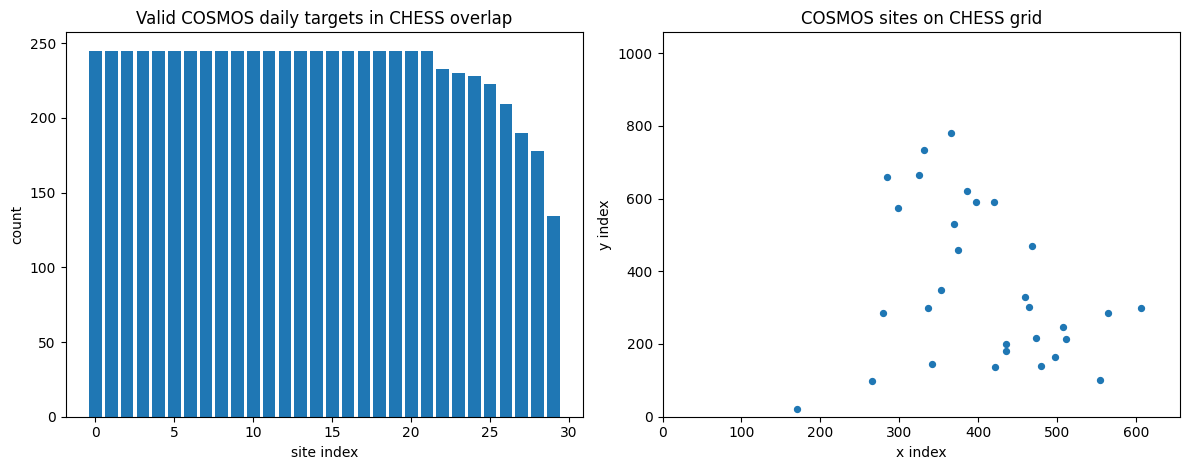

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].bar(np.arange(len(cosmos_counts)), cosmos_counts["n_obs"].values)
axes[0].set_title("Valid COSMOS daily targets in CHESS overlap")
axes[0].set_xlabel("site index")
axes[0].set_ylabel("count")

site_positions = cosmos_overlap[["SITE_ID", "EASTING", "NORTHING"]].drop_duplicates()
site_xi = np.searchsorted(xvals, site_positions["EASTING"].values)
site_yi = np.searchsorted(yvals, site_positions["NORTHING"].values)

# Avoid drawing a CHESS validity mask here, because that would read a full CHESS day.
# A simple grid extent plot is enough to check that the COSMOS sites are in range.
axes[1].scatter(site_xi, site_yi, s=18)
axes[1].set_xlim(0, len(xvals))
axes[1].set_ylim(0, len(yvals))
axes[1].set_title("COSMOS sites on CHESS grid")
axes[1].set_xlabel("x index")
axes[1].set_ylabel("y index")

plt.tight_layout()
plt.show()


The site-level minimum is only there to keep the held-out-site split meaningful. Apart from that, the downstream table uses all COSMOS observations that overlap the loaded CHESS-Met period.


## Build the downstream table


In [16]:

usable_sites = cosmos_counts.loc[cosmos_counts["n_obs"] >= MIN_SITE_OBS, "SITE_ID"].tolist()
assert usable_sites, "no COSMOS sites have enough observations after the CHESS overlap filter"

# Fast lookup from calendar date to CHESS time index.
time_lookup = {pd.Timestamp(t): i for i, t in enumerate(chess_times)}

# Raw summary columns are only for checks/plots. The model uses the standardised
# 7-day met_window with all selected CHESS variables.
met_summary_cols = [f"{v}_7d_mean" for v in chess_variables]

# Build the site/date requests first, then read CHESS windows in batches.
requests = []

for site_id in usable_sites:
    site_df = (
        cosmos_overlap.loc[cosmos_overlap["SITE_ID"] == site_id]
        .sort_values("DATE_TIME")
        .reset_index(drop=True)
    )

    site_x = float(site_df["EASTING"].iloc[0])
    site_y = float(site_df["NORTHING"].iloc[0])
    land_vec = read_landcover_vector(site_x, site_y)

    xi = int(np.argmin(np.abs(xvals - site_x)))
    yi = int(np.argmin(np.abs(yvals - site_y)))

    for _, row in site_df.iterrows():
        date = pd.Timestamp(row["DATE_TIME"])
        time_idx = time_lookup.get(date)

        # Require a complete 7-day history ending on the COSMOS target date.
        if time_idx is None or time_idx < WINDOW_DAYS - 1:
            continue

        target = float(row["COSMOS_VWC"])
        if not np.isfinite(target):
            continue

        requests.append(
            {
                "SITE_ID": site_id,
                "SITE_NAME": row["SITE_NAME"],
                "DATE_TIME": date,
                "target": target,
                "land_vec": land_vec,
                "EASTING": site_x,
                "NORTHING": site_y,
                "SOIL_TYPE": row["SOIL_TYPE"],
                "LAND_COVER": row["LAND_COVER"],
                "time_idx": int(time_idx),
                "yi": int(yi),
                "xi": int(xi),
            }
        )

downstream_rows = []

for start in range(0, len(requests), DOWNSTREAM_CHESS_BATCH_SIZE):
    batch = requests[start: start + DOWNSTREAM_CHESS_BATCH_SIZE]

    raw_batch, norm_batch = read_chess_windows_batched(
        [r["time_idx"] for r in batch],
        [r["yi"] for r in batch],
        [r["xi"] for r in batch],
    )

    for req, raw_window, norm_window in zip(batch, raw_batch, norm_batch):
        if not np.isfinite(raw_window).all():
            continue

        summary_values = raw_window.mean(axis=0)
        out_row = {
            "SITE_ID": req["SITE_ID"],
            "SITE_NAME": req["SITE_NAME"],
            "DATE_TIME": req["DATE_TIME"],
            "target": req["target"],
            "land_vec": req["land_vec"],
            "met_window": np.nan_to_num(norm_window, nan=0.0, posinf=0.0, neginf=0.0).astype("float32"),
            "EASTING": req["EASTING"],
            "NORTHING": req["NORTHING"],
            "SOIL_TYPE": req["SOIL_TYPE"],
            "LAND_COVER": req["LAND_COVER"],
        }
        out_row.update({col: float(val) for col, val in zip(met_summary_cols, summary_values)})
        downstream_rows.append(out_row)

downstream_df = pd.DataFrame(downstream_rows).sort_values(["SITE_ID", "DATE_TIME"]).reset_index(drop=True)
assert not downstream_df.empty, "downstream table is empty after requiring complete CHESS windows"

print("usable sites:", usable_sites)
print("candidate COSMOS/CHESS requests:", len(requests))
print("downstream rows:", len(downstream_df))
downstream_df.head()


usable sites: ['ALIC1', 'BALRD', 'BICKL', 'BUNNY', 'CHIMN', 'CHOBH', 'CRICH', 'EASTB', 'GLENS', 'HARTW', 'HOLLN', 'LIZRD', 'MOORH', 'MORLY', 'NWYKE', 'PLYNL', 'PORTN', 'RDMER', 'ROTHD', 'SHEEP', 'STIPS', 'WADDN', 'TADHM', 'GISBN', 'LULLN', 'HARWD', 'SOURH', 'CARDT', 'COCLP', 'STGHT']
candidate COSMOS/CHESS requests: 6859
downstream rows: 6859


,SITE_ID,SITE_NAME,DATE_TIME,target,land_vec,met_window,EASTING,NORTHING,SOIL_TYPE,LAND_COVER,huss_7d_mean,precip_7d_mean
0,ALIC1,Alice Holt,2015-05-07,39.2,"[0.33663368, 0.0, 0.37623763, 0.28712872, 0.0,...","[[-0.007730573, -0.50957286], [0.4645373, 0.61...",479950.0,139985.0,Mineral soil,Broadleaf woodland,0.006603,3.469003
1,ALIC1,Alice Holt,2015-05-08,40.2,"[0.33663368, 0.0, 0.37623763, 0.28712872, 0.0,...","[[0.4645373, 0.6135218], [1.5960805, -0.509572...",479950.0,139985.0,Mineral soil,Broadleaf woodland,0.006935,3.555011
2,ALIC1,Alice Holt,2015-05-09,39.3,"[0.33663368, 0.0, 0.37623763, 0.28712872, 0.0,...","[[1.5960805, -0.50957286], [1.1441231, 0.86661...",479950.0,139985.0,Mineral soil,Broadleaf woodland,0.007099,2.580250
3,ALIC1,Alice Holt,2015-05-10,37.0,"[0.33663368, 0.0, 0.37623763, 0.28712872, 0.0,...","[[1.1441231, 0.8666135], [1.1439136, 0.4711576...",479950.0,139985.0,Mineral soil,Broadleaf woodland,0.006986,2.580250
4,ALIC1,Alice Holt,2015-05-11,35.1,"[0.33663368, 0.0, 0.37623763, 0.28712872, 0.0,...","[[1.1439136, 0.47115767], [0.79329246, -0.1615...",479950.0,139985.0,Mineral soil,Broadleaf woodland,0.007070,1.333129


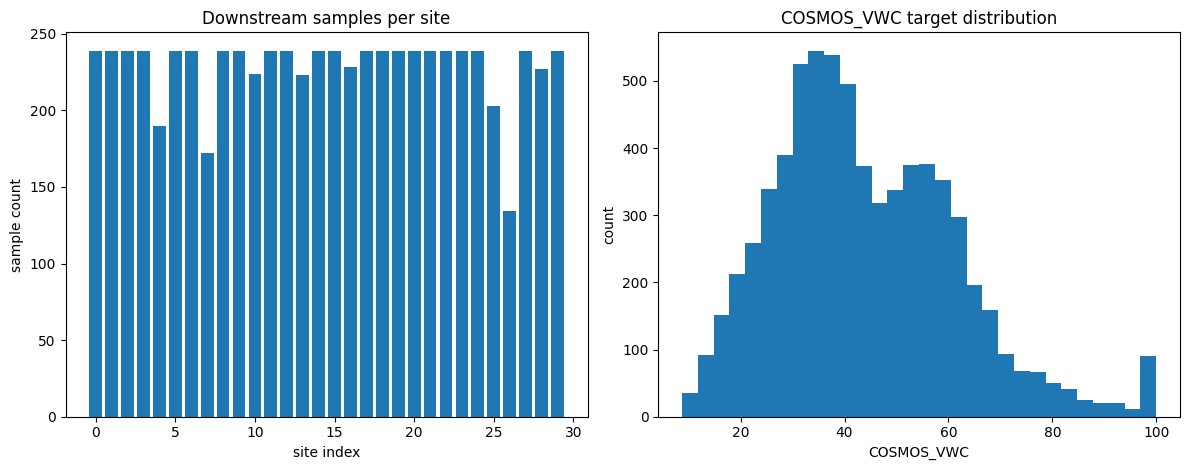

,SITE_ID,samples,mean_sm,sd_sm,mean_huss_7d_mean,mean_precip_7d_mean
0,ALIC1,239,34.176987,4.859083,0.007689,2.215431
1,BALRD,239,33.648954,4.488144,0.006491,2.827863
2,BICKL,239,29.368619,9.507444,0.007275,1.893126
3,BUNNY,239,19.408787,5.647529,0.007332,1.761716
4,CARDT,190,21.264211,7.134497,0.007717,1.606596


In [17]:
agg_dict = {
    "samples": ("target", "size"),
    "mean_sm": ("target", "mean"),
    "sd_sm": ("target", "std"),
}

# Include a couple of CHESS summaries if they are present, without assuming the exact
# variable names in the local archive.
for col in met_summary_cols[:2]:
    agg_dict[f"mean_{col}"] = (col, "mean")

site_level = (
    downstream_df.groupby("SITE_ID")
    .agg(**agg_dict)
    .reset_index()
    .sort_values("SITE_ID")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].bar(np.arange(len(site_level)), site_level["samples"].values)
axes[0].set_title("Downstream samples per site")
axes[0].set_xlabel("site index")
axes[0].set_ylabel("sample count")

axes[1].hist(downstream_df["target"].values, bins=30)
axes[1].set_title("COSMOS_VWC target distribution")
axes[1].set_xlabel("COSMOS_VWC")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

site_level.head()


At this stage each supervised row contains the COSMOS target, the static LCM vector at the site, and the matching 7-day CHESS-Met window.


## Downstream regression


In [18]:
Xl = torch.tensor(np.stack(downstream_df["land_vec"].to_list()), dtype=torch.float32).to(DEVICE)
Xm = torch.tensor(
    np.stack([window.reshape(-1) for window in downstream_df["met_window"]]),
    dtype=torch.float32,
).to(DEVICE)
y = torch.tensor(downstream_df["target"].values.astype("float32")).view(-1, 1).to(DEVICE)

# Held-out-site split: this is closer to the way the downstream model would be used
# at locations not seen during fitting.
site_ids = sorted(downstream_df["SITE_ID"].unique())
rng = np.random.default_rng(42)

n_test_sites = max(1, int(np.ceil(0.3 * len(site_ids))))
test_sites = sorted(rng.choice(site_ids, size=n_test_sites, replace=False).tolist())
train_sites = [s for s in site_ids if s not in test_sites]

train_mask = downstream_df["SITE_ID"].isin(train_sites)
test_mask = downstream_df["SITE_ID"].isin(test_sites)

# Tensor masks need to be on the same device as the tensors they index.
train_mask_t = torch.tensor(train_mask.values, dtype=torch.bool, device=DEVICE)
test_mask_t = torch.tensor(test_mask.values, dtype=torch.bool, device=DEVICE)

print("Train sites:", train_sites)
print("Test sites:", test_sites)


class DownstreamRegressor(nn.Module):
    def __init__(self, pretrained):
        super().__init__()
        self.space = pretrained.space
        self.met = pretrained.met
        self.head = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, land, met):
        z = torch.cat([self.space(land), self.met(met)], dim=1)
        return self.head(z)


reg_model = DownstreamRegressor(pretrain_model).to(DEVICE)

# Warm-start the regression head, then fine-tune the encoders on COSMOS.
for p in list(reg_model.space.parameters()) + list(reg_model.met.parameters()):
    p.requires_grad = False

opt = torch.optim.Adam(filter(lambda p: p.requires_grad, reg_model.parameters()), lr=1e-2)
warm_history = []

for epoch in range(120):
    opt.zero_grad()
    pred = reg_model(Xl[train_mask_t], Xm[train_mask_t])
    loss = F.mse_loss(pred, y[train_mask_t])
    loss.backward()
    opt.step()
    warm_history.append(float(loss.item()))

for p in reg_model.parameters():
    p.requires_grad = True

opt = torch.optim.Adam(reg_model.parameters(), lr=1e-3)
finetune_history = []

for epoch in range(120):
    opt.zero_grad()
    pred = reg_model(Xl[train_mask_t], Xm[train_mask_t])
    loss = F.mse_loss(pred, y[train_mask_t])
    loss.backward()
    opt.step()
    finetune_history.append(float(loss.item()))

with torch.no_grad():
    train_pred = reg_model(Xl[train_mask_t], Xm[train_mask_t]).detach().cpu().numpy().ravel()
    test_pred = reg_model(Xl[test_mask_t], Xm[test_mask_t]).detach().cpu().numpy().ravel()

train_obs = y[train_mask_t].detach().cpu().numpy().ravel()
test_obs = y[test_mask_t].detach().cpu().numpy().ravel()

metrics = pd.DataFrame(
    [
        {
            "split": "train",
            "rmse": mean_squared_error(train_obs, train_pred) ** 0.5,
            "r2": r2_score(train_obs, train_pred),
            "n": int(train_mask.sum()),
        },
        {
            "split": "test",
            "rmse": mean_squared_error(test_obs, test_pred) ** 0.5,
            "r2": r2_score(test_obs, test_pred),
            "n": int(test_mask.sum()),
        },
    ]
)
metrics


Train sites: ['ALIC1', 'BUNNY', 'CARDT', 'CHIMN', 'COCLP', 'CRICH', 'EASTB', 'HARTW', 'HARWD', 'HOLLN', 'LULLN', 'MORLY', 'NWYKE', 'PORTN', 'RDMER', 'SHEEP', 'SOURH', 'STGHT', 'STIPS', 'TADHM', 'WADDN']
Test sites: ['BALRD', 'BICKL', 'CHOBH', 'GISBN', 'GLENS', 'LIZRD', 'MOORH', 'PLYNL', 'ROTHD']


,split,rmse,r2,n
0,train,11.692402,0.586204,4723
1,test,13.312118,0.210402,2136


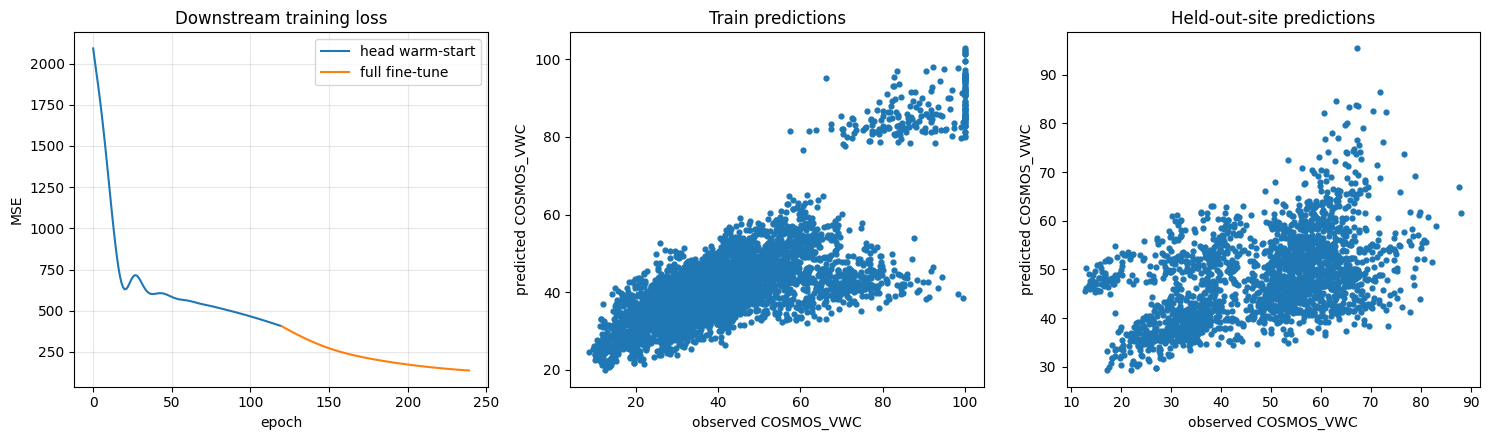

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(warm_history, label="head warm-start")
axes[0].plot(
    np.arange(len(warm_history), len(warm_history) + len(finetune_history)),
    finetune_history,
    label="full fine-tune",
)
axes[0].set_title("Downstream training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(train_obs, train_pred, s=12)
axes[1].set_title("Train predictions")
axes[1].set_xlabel("observed COSMOS_VWC")
axes[1].set_ylabel("predicted COSMOS_VWC")

axes[2].scatter(test_obs, test_pred, s=12)
axes[2].set_title("Held-out-site predictions")
axes[2].set_xlabel("observed COSMOS_VWC")
axes[2].set_ylabel("predicted COSMOS_VWC")

plt.tight_layout()
plt.show()


This is a deliberately compact transfer test. The encoders come from the pretraining step, then a small regression head is fitted on COSMOS soil moisture. The split is by site, so the test set checks transfer to held-out locations rather than just interpolation through time at the same site.


## Local inference check

As a final quick check, I apply the downstream model to a small grid around one COSMOS site. This is not a validation product; it is just a visual check that the trained pipeline can produce spatial predictions from CHESS + LCM inputs.


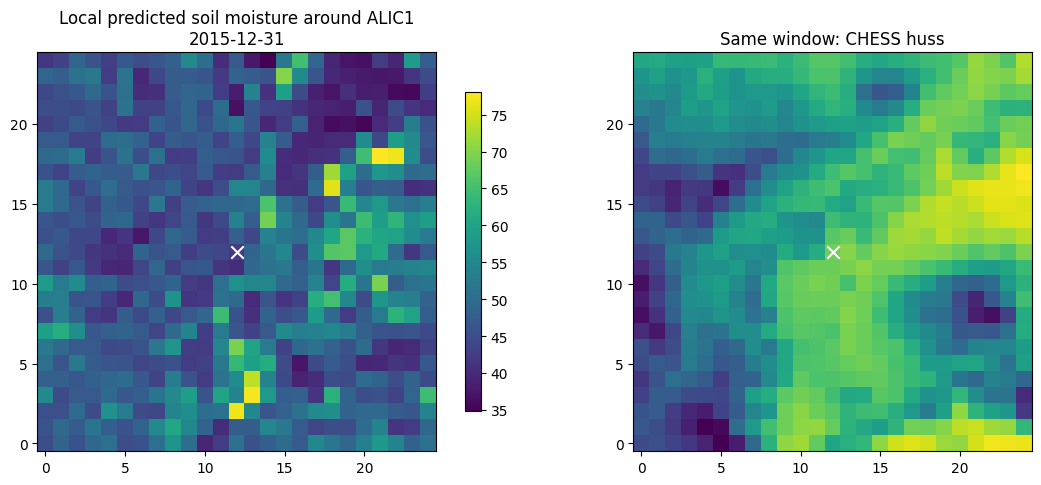

In [20]:

target_site = usable_sites[0]
site_records = downstream_df.loc[downstream_df["SITE_ID"] == target_site].sort_values("DATE_TIME")
target_date = pd.Timestamp(site_records["DATE_TIME"].iloc[-1])

site_row = site_meta.loc[site_meta["SITE_ID"] == target_site].iloc[0]
site_x = float(site_row["EASTING"])
site_y = float(site_row["NORTHING"])

target_t = time_lookup[target_date]
site_col = int(np.argmin(np.abs(xvals - site_x)))
site_row_idx = int(np.argmin(np.abs(yvals - site_y)))

radius = 12
ys = np.arange(max(0, site_row_idx - radius), min(len(yvals), site_row_idx + radius + 1))
xs = np.arange(max(0, site_col - radius), min(len(xvals), site_col + radius + 1))

yy_grid, xx_grid = np.meshgrid(ys, xs, indexing="ij")
flat_y = yy_grid.reshape(-1)
flat_x = xx_grid.reshape(-1)
flat_t = np.full_like(flat_y, target_t)

raw_flat, norm_flat = read_chess_windows_batched(flat_t, flat_y, flat_x)
land_flat = read_landcover_batch(xvals[flat_x], yvals[flat_y])

met_flat = np.nan_to_num(norm_flat, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
finite_mask = np.isfinite(raw_flat).all(axis=(1, 2)) & (land_flat.sum(axis=1) > 0)

pred_flat = np.full(len(flat_y), np.nan, dtype="float32")
if finite_mask.any():
    with torch.no_grad():
        pred_flat[finite_mask] = (
            reg_model(
                torch.tensor(land_flat[finite_mask], dtype=torch.float32, device=DEVICE),
                torch.tensor(met_flat[finite_mask].reshape(finite_mask.sum(), -1), dtype=torch.float32, device=DEVICE),
            )
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
            .astype("float32")
        )

pred_map = pred_flat.reshape(len(ys), len(xs))
raw_block = raw_flat.reshape(len(ys), len(xs), WINDOW_DAYS, len(chess_variables)).transpose(2, 0, 1, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

im0 = axes[0].imshow(pred_map, origin="lower")
axes[0].set_title(f"Local predicted soil moisture around {target_site}\n{target_date.date()}")
axes[0].scatter(site_col - xs[0], site_row_idx - ys[0], marker="x", s=80, color="white")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

plot_var = chess_variables[0]
axes[1].imshow(raw_block[-1, :, :, 0], origin="lower")
axes[1].set_title(f"Same window: CHESS {plot_var}")
axes[1].scatter(site_col - xs[0], site_row_idx - ys[0], marker="x", s=80, color="white")

plt.tight_layout()
plt.show()


## Notes

This notebook is meant as a readable FRAME-FM demonstration rather than a tuned benchmark.

For quick test runs, reduce `SAMPLES_PER_PRETRAIN_EPOCH` or set `PRETRAIN_MAX_BATCHES_PER_EPOCH` near the top of the notebook. For larger CHESS windows or more variables, the project-style Zarr cache is the better long-term route than keeping the selected period in memory.
